### Import the libraries and Load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sales =pd.read_csv(r"/Users/nico/Documents/Ironhack/Week2/W2D5/Project 1/sales.csv")
df_sales.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


### Exploratory Data Analysis (EDA)

In [2]:
df_sales.shape

(640840, 10)

In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [4]:
df_sales.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [5]:
df_sales['date']=pd.to_datetime(df_sales['date'])

In [6]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0           640840 non-null  int64         
 1   store_ID             640840 non-null  int64         
 2   day_of_week          640840 non-null  int64         
 3   date                 640840 non-null  datetime64[ns]
 4   nb_customers_on_day  640840 non-null  int64         
 5   open                 640840 non-null  int64         
 6   promotion            640840 non-null  int64         
 7   state_holiday        640840 non-null  object        
 8   school_holiday       640840 non-null  int64         
 9   sales                640840 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 48.9+ MB


In [7]:
df_sales['state_holiday'].value_counts()

state_holiday
0    621160
a     12842
b      4214
c      2624
Name: count, dtype: int64

In [8]:
df_sales = df_sales.drop(columns=['Unnamed: 0', 'date' ], axis=1)

In [9]:
df_sales.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,366,4,517,1,0,0,0,4422
1,394,6,694,1,0,0,0,8297
2,807,4,970,1,1,0,0,9729
3,802,2,473,1,1,0,0,6513
4,726,4,1068,1,1,0,0,10882


In [10]:
df_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
store_ID,640840.0,558.211348,321.878521,1.0,280.0,558.0,837.0,1115.0
day_of_week,640840.0,4.000189,1.996478,1.0,2.0,4.0,6.0,7.0
nb_customers_on_day,640840.0,633.398577,464.094416,0.0,405.0,609.0,838.0,5458.0
open,640840.0,0.830185,0.375470,0.0,1.0,1.0,1.0,1.0
promotion,640840.0,0.381718,0.485808,0.0,0.0,0.0,1.0,1.0
school_holiday,640840.0,0.178472,0.382910,0.0,0.0,0.0,0.0,1.0
sales,640840.0,5777.469011,3851.338083,0.0,3731.0,5746.0,7860.0,41551.0


In [11]:
df_sales['store_ID'].value_counts()

store_ID
1045    645
309     636
754     635
432     634
286     634
       ... 
1004    448
287     448
1065    445
81      438
542     436
Name: count, Length: 1115, dtype: int64

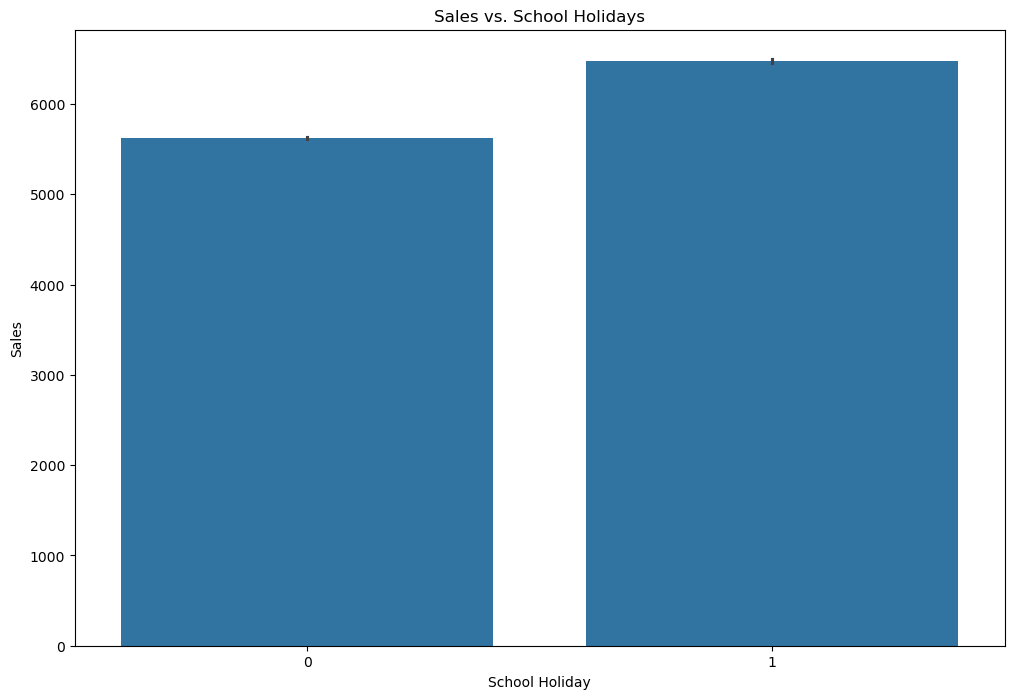

In [12]:
plt.figure(figsize=(12,8))

sns.barplot(data =df_sales, x='school_holiday', y ='sales')
plt.title("Sales vs. School Holidays")
plt.xlabel("School Holiday")
plt.ylabel("Sales")
plt.show()

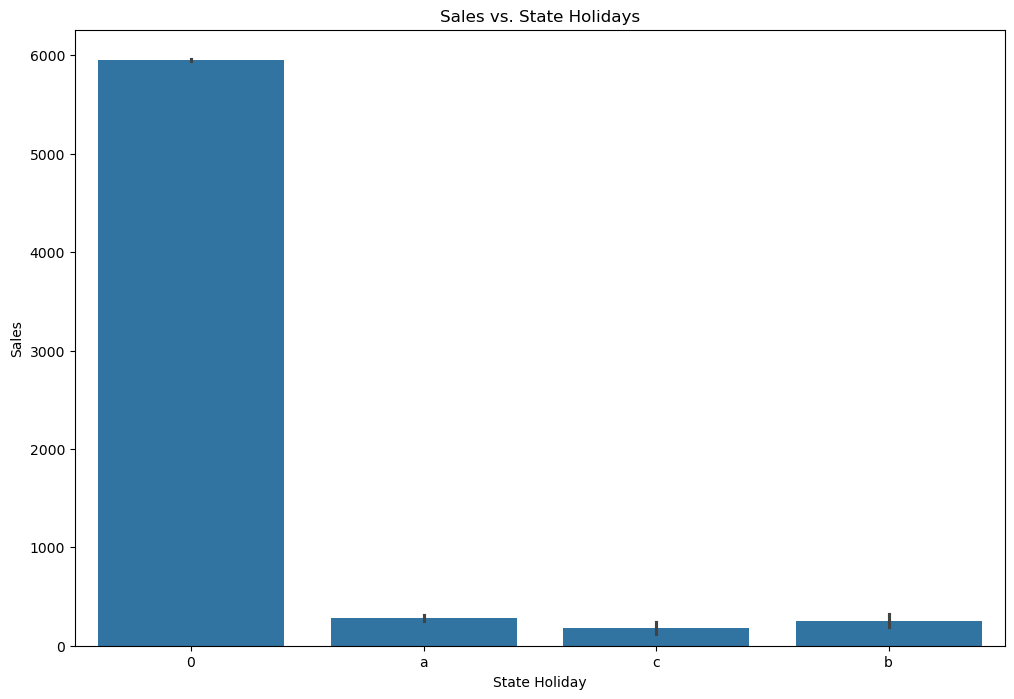

In [13]:
plt.figure(figsize=(12,8))

sns.barplot(data =df_sales, x='state_holiday', y ='sales')
plt.title("Sales vs. State Holidays")
plt.xlabel("State Holiday")
plt.ylabel("Sales")
plt.show()

In [14]:
df_sales.nunique()

store_ID                1115
day_of_week                7
nb_customers_on_day     3886
open                       2
promotion                  2
state_holiday              4
school_holiday             2
sales                  20129
dtype: int64

In [15]:
df_sales['school_holiday'].value_counts()

school_holiday
0    526468
1    114372
Name: count, dtype: int64

### Sales Vs. Store ID

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X = df_sales.drop('sales', axis=1)
y = df_sales['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train[['state_holiday']])
X_test_cat = encoder.transform(X_test[['state_holiday']])

print("Training set size: ", X_train.shape[0])
print("Test set size:     ", X_test.shape[0])

Training set size:  512672
Test set size:      128168


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# remove columns we don't want
X = df_sales.drop(["sales", "state_holiday", "school_holiday"], axis=1)

# target column
y = df_sales["sales"]

# split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 992.0893232063343
RMSE: 1488.6890456019069
R²: 0.8500713129812145


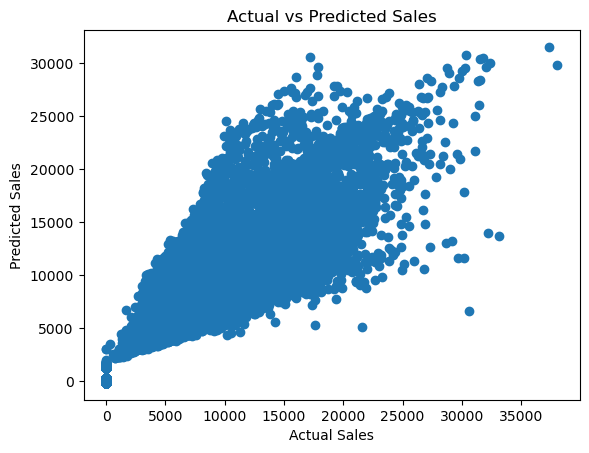

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()